# Pipeline de ML — Predicción de riesgo crediticio

**Curso:** Computación de Alto Desempeño y Cloud Computing  
**Docente:** MSc Juan Carlos Tovar Galarreta  
**Grupo 2:** Córdova, Guevara, Medina, Quiñones

---

Como uno de los objetivo del proyecto del diseño e implementación de un pipeline de ML se evalúa cuánto se puede reducir el tiempo de preprocesamiento y entrenamiento 
de modelos de clasificación crediticia cuando se combinan dos tipos de paralelismo:
uno a nivel de tareas (varias configuraciones entrenando al mismo tiempo) y otro
a nivel de datos (cada modelo usando todos los núcleos del procesador internamente).

El dataset es el *Home Credit Default Risk* de Kaggle, que tiene más de 300 mil registros
y 122 variables. La variable objetivo (`TARGET`) indica si un cliente incumplió su préstamo.

In [1]:
import os
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, classification_report

## Fases 1 a 4: carga, limpieza, preprocesamiento y separación

Las cuatro primeras fases preparan los datos antes del entrenamiento.
En esta versión el preprocesamiento es completamente secuencial, ya que
el análisis de escalabilidad se concentra únicamente en la fase de entrenamiento. La estrategia de unir train y test antes del preprocesamiento (con
un marcador `TARGET=2` en el conjunto de prueba) garantiza que la
imputación vea la misma distribución de datos en ambos conjuntos.

In [2]:
# --- FASE 1: Carga y corrección inicial ---
def cargar_y_corregir_datos(ruta_train, ruta_test, col_anomala=None, valor_anomalo=None, verbose=True):
    if verbose:
        print("=" * 60)
        print(" FASE 1: CARGA DE DATOS Y CORRECCIÓN DE ANOMALÍAS")
        print("=" * 60)

    train = pd.read_csv(ruta_train)
    test = pd.read_csv(ruta_test)

    if col_anomala and valor_anomalo is not None:
        # # El valor 365243 en DAYS_EMPLOYED equivale a más de 1000 años de empleo por lo que al ser un valor
        #atipico lo convertiremos en nulo para que no distorsione la distribución de su variable.
        train[col_anomala] = train[col_anomala].replace(valor_anomalo, np.nan)
        test[col_anomala] = test[col_anomala].replace(valor_anomalo, np.nan)
        if verbose:
            print(f" Anomalía corregida en la columna '{col_anomala}'.")
    if verbose:
        print(f"Tamaño Train: {train.shape} | Tamaño Test: {test.shape}")
    return train, test


# --- FASE 2: Unión y limpieza de nulos excesivos ---
def limpiar_nulos_excesivos(train, test, umbral_obs=0.5, umbral_attr=0.6, auto_eliminar=True, verbose=True):
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 2: LIMPIEZA DE NULOS ")
        print("=" * 60)

    train_copy = train.copy()
    test_copy = test.copy()
    test_copy['TARGET'] = 2  # se le asigna un valor de target imaginario para poder identificar los datos test

    df = pd.concat([train_copy, test_copy], axis=0, ignore_index=True)

    predictoras = df.drop(columns=['TARGET'])
    n_obs, n_attr = predictoras.shape

    # Eliminar filas que tienen más del umbral de sus valores como NaN
    obs_muchos_vacios = (predictoras.isnull().sum(axis=1) / n_attr) >= umbral_obs
    if obs_muchos_vacios.sum() > 0 and auto_eliminar:
        df = df.loc[~obs_muchos_vacios]
        if verbose:
            print(f"Se eliminaron {obs_muchos_vacios.sum()} filas por exceso de nulos.")

    # Eliminar columnas con una proporción de nulos mayor al umbral
    # Se recalcula predictoras porque el shape cambió si se eliminaron filas
    predictoras = df.drop(columns=['TARGET'])
    n_obs, n_attr = predictoras.shape
    attr_muchos_vacios = (predictoras.isnull().sum(axis=0) / n_obs) >= umbral_attr
    if attr_muchos_vacios.sum() > 0 and auto_eliminar:
        cols_a_mantener = predictoras.columns[~attr_muchos_vacios].tolist() + ['TARGET']
        df = df[cols_a_mantener]
        if verbose:
            print(f"Se eliminaron {attr_muchos_vacios.sum()} columnas por exceso de nulos.")
    if verbose:
        print(f"Dimensiones tras limpieza: {df.shape}")
    return df


In [8]:
# --- Bloques individuales de imputación ---
def _imputar_categoricas(df, cols_categoricas):
    if not cols_categoricas:
        return pd.DataFrame()
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Desconocido')
    bloque = pd.DataFrame(
        imputer_cat.fit_transform(df[cols_categoricas]),
        columns=cols_categoricas,
        index=df.index
    )
    # LightGBM y XGBoost esperan el tipo 'category' para su manejo nativo de categóricas
    for col in cols_categoricas:
        bloque[col] = bloque[col].astype(str).astype('category')
    return bloque


def _imputar_y_escalar_continuas(df, cols_continuas):
    if not cols_continuas:
        return pd.DataFrame()
    # La mediana es más robusta que la media ante los valores extremos
    # que son habituales en variables financieras (ingresos, montos de crédito)
    imputer_num = SimpleImputer(strategy='median')
    valores_imputados = imputer_num.fit_transform(df[cols_continuas])
    # RobustScaler normaliza usando el rango intercuartílico
    scaler = RobustScaler()
    valores_escalados = scaler.fit_transform(valores_imputados)
    bloque = pd.DataFrame(valores_escalados, columns=cols_continuas, index=df.index)
    return bloque

def _imputar_enteras(df, cols_enteras):
    if not cols_enteras:
        return pd.DataFrame()
    imputer_int = SimpleImputer(strategy='median')
    valores = imputer_int.fit_transform(df[cols_enteras])
    bloque = pd.DataFrame(valores, columns=cols_enteras, index=df.index)
    # Int64 con mayúscula (nullable integer) permite conservar NaN si los hubiera
    bloque = bloque.round().astype('Int64')
    return bloque


def _detectar_tipo_columna(serie, umbral_categorica=0.05):
    """
    Clasifica una columna numérica en 'categorica', 'entera' o 'continua'
    aplicando dos reglas de negocio en orden:

    1. Cardinalidad relativa: si la proporción de valores únicos sobre el total
       de registros es menor al umbral (por defecto 5%), la columna se trata
       como categórica. Ejemplo: una columna con 15 valores únicos sobre
       300 000 filas tiene cardinalidad 0.005%, muy por debajo del umbral.

    2. Presencia de decimales: si todos los valores no nulos son enteros
       (no hay parte decimal), se trata como entera (conteos, días, flags).
       Si hay decimales, es continua (montos, ratios, porcentajes).
    """
    valores_no_nulos = serie.dropna()
    if len(valores_no_nulos) == 0:
        return 'continua'

    # Regla 1: cardinalidad relativa
    cardinalidad = serie.nunique() / len(serie)
    if cardinalidad < umbral_categorica:
        return 'categorica'

    # Regla 2: presencia de decimales
    if (valores_no_nulos % 1 == 0).all():
        return 'entera'

    return 'continua'


def _clasificar_columnas_auto(df, umbral_categorica=0.05, verbose=True):
    """
    Clasifica automáticamente todas las columnas del dataframe
    usando las reglas de negocio de _detectar_tipo_columna.
    """
    cols_object = df.select_dtypes(include=['object']).columns.tolist()
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    if 'TARGET' in cols_numericas:
        cols_numericas.remove('TARGET')

    cols_categoricas = list(cols_object)
    cols_enteras = []
    cols_continuas = []

    for col in cols_numericas:
        tipo = _detectar_tipo_columna(df[col], umbral_categorica)
        if tipo == 'categorica':
            cols_categoricas.append(col)
        elif tipo == 'entera':
            cols_enteras.append(col)
        else:
            cols_continuas.append(col)

    if verbose:
        print(f"Detección automática: {len(cols_categoricas)} categóricas, "
              f"{len(cols_continuas)} continuas, {len(cols_enteras)} enteras")

    return cols_categoricas, cols_continuas, cols_enteras


# --- FASE 3: Preprocesamiento con detección automática ---
def preprocesar_datos(df_unido, umbral_categorica=0.05, verbose=True):
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 3: PREPROCESAMIENTO")
        print("=" * 60)

    df = df_unido.copy()

    cols_categoricas, cols_continuas, cols_enteras = _clasificar_columnas_auto(
        df, umbral_categorica=umbral_categorica, verbose=verbose
    )

    bloque_cat  = _imputar_categoricas(df, cols_categoricas)
    bloque_cont = _imputar_y_escalar_continuas(df, cols_continuas)
    bloque_int  = _imputar_enteras(df, cols_enteras)

    # Reensamblar los bloques procesados en el dataframe original
    if not bloque_cat.empty:
        df[cols_categoricas] = bloque_cat
    if not bloque_cont.empty:
        df[cols_continuas] = bloque_cont
    if not bloque_int.empty:
        df[cols_enteras] = bloque_int

    return df


# --- FASE 4: Separación de Sets ---
def preparar_sets_entrenamiento(df_procesado, test_size=0.20, random_state=42, verbose=True):
    if verbose:
        print("\n" + "=" * 60)
        print(" FASE 4: SEPARACIÓN DE SETS DE DATOS")
        print("=" * 60)

    # Se recuperan los registros usando el marcador TARGET = 2 del conjunto de prueba
    train_limpio = df_procesado[df_procesado['TARGET'].isin([0, 1])].copy()
    test_limpio  = df_procesado[df_procesado['TARGET'] == 2].copy()

    X = train_limpio.drop(columns=['TARGET'])
    y = train_limpio['TARGET'].astype(int)
    X_test_final = test_limpio.drop(columns=['TARGET'])

    # stratify=y preserva la proporción de impagos (8%) en train y validación
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    if verbose:
        print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test Final: {X_test_final.shape}")
    return X_train, X_val, y_train, y_val, X_test_final


## Funciones de entrenamiento

Cada función entrena un modelo con una configuración de hiperparámetros y devuelve
un diccionario con las métricas y el tiempo. Para LightGBM se usa `is_unbalance=True`, ajusta internamente los pesos de las
clases para compensar el desbalance 11:1 del dataset. Para XGBoost se usa
`scale_pos_weight`, que cumple la misma función pero requiere que el valor se calcule
manualmente como la razón entre la clase negativa y la positiva.

In [9]:
def entrenar_lightgbm(X_train, y_train, X_val, y_val, config_id='LGB-default',
                       learning_rate=0.05, num_leaves=31, num_boost_round=1000,
                       n_jobs=-1):
    t0 = time.time()

    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': learning_rate,
        'num_leaves': num_leaves,
        'n_jobs': n_jobs,        # activa OpenMP: distribuye histogramas entre núcleos
        'is_unbalance': True,    # compensa el desbalance de clases 11:1 internamente
        'verbose': -1
    }

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]

    modelo_lgb = lgb.train(
        params, train_data,
        num_boost_round=num_boost_round,
        valid_sets=[train_data, val_data],
        callbacks=callbacks
    )

    y_pred_prob = modelo_lgb.predict(X_val)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    tf = time.time() - t0

    print(f"  [{config_id}] LightGBM | AUC: {auc:.4f} | F1: {f1:.4f} | Tiempo: {tf:.2f}s")

    return {
        'config_id': config_id,
        'modelo': 'LightGBM',
        'params': {'learning_rate': learning_rate, 'num_leaves': num_leaves},
        'roc_auc': auc,
        'f1_score': f1,
        'tiempo': tf
    }


def entrenar_xgboost(X_train, y_train, X_val, y_val, config_id='XGB-default',
                      learning_rate=0.05, max_depth=6, num_boost_round=1000,
                      scale_weight=1.0, n_jobs=-1):
    t0 = time.time()

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',  
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'n_jobs': n_jobs,             
        'scale_pos_weight': scale_weight, 
        'random_state': 42
    }

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

    evals = [(dtrain, 'entrenamiento'), (dval, 'validacion')]

    modelo_xgb = xgb.train(
        params, dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    y_pred_prob = modelo_xgb.predict(dval)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred_class)
    tf = time.time() - t0

    print(f"  [{config_id}] XGBoost  | AUC: {auc:.4f} | F1: {f1:.4f} | Tiempo: {tf:.2f}s")

    return {
        'config_id': config_id,
        'modelo': 'XGBoost',
        'params': {'learning_rate': learning_rate, 'max_depth': max_depth},
        'roc_auc': auc,
        'f1_score': f1,
        'tiempo': tf
    }


## Definición del grid de hiperparámetros

8 entrenamientos en total: 4 configuraciones × 2 modelos. Los parámetros elegidos para variar son los que más influyen sobre el rendimiento
predictivo y sobre el tiempo de entrenamiento: `learning_rate`, `num_leaves`
(LightGBM, que crece hoja por hoja) y `max_depth` (XGBoost, que crece nivel por nivel).

In [10]:
# 4 configuraciones de hiperparámetros para cada modelo
configs_lgb = [
    {'config_id': 'LGB-1', 'learning_rate': 0.05, 'num_leaves': 31},
    {'config_id': 'LGB-2', 'learning_rate': 0.05, 'num_leaves': 63},
    {'config_id': 'LGB-3', 'learning_rate': 0.10, 'num_leaves': 31},
    {'config_id': 'LGB-4', 'learning_rate': 0.01, 'num_leaves': 127},
]

configs_xgb = [
    {'config_id': 'XGB-1', 'learning_rate': 0.05, 'max_depth': 6},
    {'config_id': 'XGB-2', 'learning_rate': 0.05, 'max_depth': 8},
    {'config_id': 'XGB-3', 'learning_rate': 0.10, 'max_depth': 6},
    {'config_id': 'XGB-4', 'learning_rate': 0.01, 'max_depth': 10},
]

print(f"Total de modelos a entrenar: {len(configs_lgb) + len(configs_xgb)}")


Total de modelos a entrenar: 8


## Parámetros del dataset

En esta versión ya no es necesario pasar una lista manual de columnas por tipo.
La función `_clasificar_columnas_auto` detecta el tipo de cada columna numérica
usando dos reglas de negocio:

1. **Cardinalidad relativa:** si una columna tiene menos del 5% de valores únicos
   respecto al total de filas, se trata como categórica. Por ejemplo, una columna
   con 15 valores únicos sobre 300 000 filas tiene cardinalidad del 0.005%.

2. **Presencia de decimales:** si todos los valores no nulos son enteros (sin parte
   decimal), la columna se clasifica como entera. Si hay decimales, es continua.

Las columnas de tipo `object` se asignan directamente a categóricas sin evaluarlas.

In [11]:
RUTA_TRAIN = 'application_train.csv'
RUTA_TEST  = 'application_test.csv'
COLUMNA_ANOMALA = 'DAYS_EMPLOYED'
VALOR_ANOMALO   = 365243  # centinela: equivale a más de 1000 años de empleo

# Umbral de cardinalidad para la detección automática de columnas categóricas.
# Una columna con proporción de valores únicos menor a este umbral se trata como categórica.
UMBRAL_CATEGORICA = 0.05


---
## Pipeline secuencial (caso base)

Se ejecutan las cinco fases sin ningún tipo de paralelismo. El preprocesamiento
detecta los tipos de columna automáticamente y el entrenamiento usa `n_jobs=1`.
Este es el caso base contra el que se mide el speedup.

In [12]:
print("\n" + "#" * 60)
print("# EJECUCIÓN SECUENCIAL")
print("#" * 60)

tiempos_secuencial = {}
t_total_seq_start = time.time()

# --- Carga ---
t0 = time.time()
df_train_raw, df_test_raw = cargar_y_corregir_datos(
    RUTA_TRAIN, RUTA_TEST, COLUMNA_ANOMALA, VALOR_ANOMALO
)
tiempos_secuencial['Carga'] = time.time() - t0

# --- Limpieza ---
t0 = time.time()
df_unificado = limpiar_nulos_excesivos(df_train_raw, df_test_raw, auto_eliminar=True)
tiempos_secuencial['Limpieza'] = time.time() - t0

# --- Preprocesamiento ---
t0 = time.time()
df_listo = preprocesar_datos(df_unificado, umbral_categorica=UMBRAL_CATEGORICA)
tiempos_secuencial['Preprocesamiento'] = time.time() - t0

# --- Split ---
t0 = time.time()
X_train, X_val, y_train, y_val, X_test_final = preparar_sets_entrenamiento(df_listo)
tiempos_secuencial['Split'] = time.time() - t0

# El peso de la clase positiva es n_negativos / n_positivos
peso_clase_positiva = sum(y_train == 0) / sum(y_train == 1)

# --- Entrenamiento con n_jobs=1 ---
print("\n" + "=" * 60)
print(" FASE 5 (SECUENCIAL): ENTRENAMIENTO DE 8 MODELOS")
print("=" * 60)
t0 = time.time()
resultados_secuencial = []

for cfg in configs_lgb:
    res = entrenar_lightgbm(X_train, y_train, X_val, y_val, n_jobs=1, **cfg)
    resultados_secuencial.append(res)

for cfg in configs_xgb:
    res = entrenar_xgboost(X_train, y_train, X_val, y_val,
                           scale_weight=peso_clase_positiva, n_jobs=1, **cfg)
    resultados_secuencial.append(res)

tiempos_secuencial['Entrenamiento'] = time.time() - t0
tiempos_secuencial['TOTAL'] = time.time() - t_total_seq_start

print("\n" + "=" * 60)
print(" TIEMPOS SECUENCIALES")
print("=" * 60)
for fase, t in tiempos_secuencial.items():
    print(f"  {fase:<20s} {t:>8.2f}s")



############################################################
# EJECUCIÓN SECUENCIAL
############################################################
 FASE 1: CARGA DE DATOS Y CORRECCIÓN DE ANOMALÍAS
 Anomalía corregida en la columna 'DAYS_EMPLOYED'.
Tamaño Train: (307511, 122) | Tamaño Test: (48744, 121)

 FASE 2: LIMPIEZA DE NULOS 
Se eliminaron 14 filas por exceso de nulos.
Se eliminaron 17 columnas por exceso de nulos.
Dimensiones tras limpieza: (356241, 105)

 FASE 3: PREPROCESAMIENTO


C:\Users\sebas\AppData\Local\Temp\ipykernel_12192\1432080389.py:76: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = df.select_dtypes(include=['object']).columns.tolist()


Detección automática: 101 categóricas, 2 continuas, 1 enteras

 FASE 4: SEPARACIÓN DE SETS DE DATOS
Train: (245998, 104) | Val: (61500, 104) | Test Final: (48743, 104)

 FASE 5 (SECUENCIAL): ENTRENAMIENTO DE 8 MODELOS
  [LGB-1] LightGBM | AUC: 0.7185 | F1: 0.2594 | Tiempo: 56.65s
  [LGB-2] LightGBM | AUC: 0.7157 | F1: 0.2657 | Tiempo: 142.47s
  [LGB-3] LightGBM | AUC: 0.7144 | F1: 0.2625 | Tiempo: 77.86s
  [LGB-4] LightGBM | AUC: 0.7195 | F1: 0.2404 | Tiempo: 213.62s
  [XGB-1] XGBoost  | AUC: 0.6954 | F1: 0.2432 | Tiempo: 100.70s
  [XGB-2] XGBoost  | AUC: 0.6897 | F1: 0.2405 | Tiempo: 119.02s
  [XGB-3] XGBoost  | AUC: 0.6901 | F1: 0.2393 | Tiempo: 70.66s
  [XGB-4] XGBoost  | AUC: 0.6900 | F1: 0.2397 | Tiempo: 471.47s

 TIEMPOS SECUENCIALES
  Carga                    2.71s
  Limpieza                 1.00s
  Preprocesamiento        11.36s
  Split                    0.19s
  Entrenamiento         1252.57s
  TOTAL                 1267.91s


---
## Análisis de escalabilidad

Se repite el entrenamiento de las 8 configuraciones variando el número de núcleos
que cada modelo puede usar internamente (`n_jobs`). Los valores evaluados son
1, 2, 4, 8 y todos los núcleos lógicos disponibles en la máquina.

In [ ]:
import os

# Determinar el número de núcleos disponibles en la máquina
nucleos_disponibles = os.cpu_count()

# Configuraciones de núcleos a evaluar
configs_nucleos = [1, 2, 4, 8, nucleos_disponibles]
# Eliminar duplicados por si la máquina tiene exactamente 8 núcleos
configs_nucleos = sorted(set(configs_nucleos))

print(f"Núcleos disponibles en la máquina: {nucleos_disponibles}")
print(f"Configuraciones a evaluar: {configs_nucleos}")

resultados_escalabilidad = {}

for n_jobs_config in configs_nucleos:
    print("\n" + "=" * 60)
    print(f" ENTRENAMIENTO CON n_jobs={n_jobs_config}")
    print("=" * 60)

    t0 = time.time()
    resultados_iter = []

    # Se entrena cada configuración del grid con el número de núcleos indicado
    for cfg in configs_lgb:
        res = entrenar_lightgbm(X_train, y_train, X_val, y_val,
                                n_jobs=n_jobs_config, **cfg)
        resultados_iter.append(res)

    for cfg in configs_xgb:
        res = entrenar_xgboost(X_train, y_train, X_val, y_val,
                               scale_weight=peso_clase_positiva,
                               n_jobs=n_jobs_config, **cfg)
        resultados_iter.append(res)

    tiempo_total = time.time() - t0
    resultados_escalabilidad[n_jobs_config] = {
        'tiempo_entrenamiento': tiempo_total,
        'resultados': resultados_iter
    }
    print(f"  Tiempo total con n_jobs={n_jobs_config}: {tiempo_total:.2f}s")
n_jobs_vals = list(resultados_escalabilidad.keys())

Núcleos disponibles en la máquina: 22
Configuraciones a evaluar: [1, 2, 4, 8, 22]

 ENTRENAMIENTO CON n_jobs=1
  [LGB-1] LightGBM | AUC: 0.7185 | F1: 0.2594 | Tiempo: 31.99s
  [LGB-2] LightGBM | AUC: 0.7157 | F1: 0.2657 | Tiempo: 40.60s
  [LGB-3] LightGBM | AUC: 0.7144 | F1: 0.2625 | Tiempo: 21.28s
  [LGB-4] LightGBM | AUC: 0.7195 | F1: 0.2404 | Tiempo: 110.86s
  [XGB-1] XGBoost  | AUC: 0.6954 | F1: 0.2432 | Tiempo: 74.20s
  [XGB-2] XGBoost  | AUC: 0.6897 | F1: 0.2405 | Tiempo: 80.52s
  [XGB-3] XGBoost  | AUC: 0.6901 | F1: 0.2393 | Tiempo: 44.29s
  [XGB-4] XGBoost  | AUC: 0.6900 | F1: 0.2397 | Tiempo: 393.19s
  Tiempo total con n_jobs=1: 797.03s

 ENTRENAMIENTO CON n_jobs=2
  [LGB-1] LightGBM | AUC: 0.7185 | F1: 0.2594 | Tiempo: 29.45s
  [LGB-2] LightGBM | AUC: 0.7157 | F1: 0.2657 | Tiempo: 34.80s
  [LGB-3] LightGBM | AUC: 0.7144 | F1: 0.2625 | Tiempo: 17.95s
  [LGB-4] LightGBM | AUC: 0.7195 | F1: 0.2404 | Tiempo: 96.40s
  [XGB-1] XGBoost  | AUC: 0.6954 | F1: 0.2432 | Tiempo: 48.71s
  

## Resultados del análisis de escalabilidad

Se calcula el speedup de cada configuración respecto al caso base (n_jobs=1)
y se compara con el speedup ideal (lineal). La diferencia entre ambas curvas
muestra el overhead real causado por la contención de recursos cuando
varios procesos compiten por los mismos núcleos físicos.

In [17]:
# Tiempo de referencia: n_jobs=1
t_base = resultados_escalabilidad[1]['tiempo_entrenamiento']

print("=" * 60)
print(" RESULTADOS DE ESCALABILIDAD")
print("=" * 60)
print(f"{'n_jobs':<10} {'Tiempo (s)':>12} {'Speedup':>10} {'Speedup ideal':>14}")
print("-" * 50)

for n, datos in resultados_escalabilidad.items():
    t = datos['tiempo_entrenamiento']
    speedup = t_base / t
    speedup_ideal = float(n)  # speedup lineal teórico
    print(f"  {n:<8} {t:>12.2f}s {speedup:>10.2f}x {speedup_ideal:>13.1f}x")

# Mostrar métricas predictivas del primer modelo (LGB-1) para verificar reproducibilidad
print("\n" + "=" * 60)
print(" MÉTRICAS PREDICTIVAS (LGB-1, verificación de reproducibilidad)")
print("=" * 60)
print(f"{'n_jobs':<10} {'AUC-ROC':>10} {'F1-score':>10}")
print("-" * 35)
for n, datos in resultados_escalabilidad.items():
    primer_modelo = datos['resultados'][0]
    print(f"  {n:<8} {primer_modelo['roc_auc']:>10.4f} {primer_modelo['f1_score']:>10.4f}")


 RESULTADOS DE ESCALABILIDAD
n_jobs       Tiempo (s)    Speedup  Speedup ideal
--------------------------------------------------
  1              797.03s       1.00x           1.0x
  2              546.98s       1.46x           2.0x
  4              512.15s       1.56x           4.0x
  8              477.03s       1.67x           8.0x
  22             378.09s       2.11x          22.0x

 MÉTRICAS PREDICTIVAS (LGB-1, verificación de reproducibilidad)
n_jobs        AUC-ROC   F1-score
-----------------------------------
  1            0.7185     0.2594
  2            0.7185     0.2594
  4            0.7185     0.2594
  8            0.7185     0.2594
  22           0.7185     0.2594


## Tabla combinada: AUC-ROC × Speedup × n_jobs

Combina el rendimiento predictivo de cada configuración con el speedup
obtenido según el número de núcleos. Permite identificar qué combinación
de modelo y núcleos ofrece el mejor balance entre calidad predictiva y
eficiencia computacional.

In [18]:
# Construir la tabla combinada AUC-ROC x Speedup x n_jobs
filas = []
for n in n_jobs_vals:
    t_total_n = resultados_escalabilidad[n]['tiempo_entrenamiento']
    speedup_n = t_base / t_total_n

    for res in resultados_escalabilidad[n]['resultados']:
        # Tiempo individual del modelo con n_jobs=1 (referencia por configuración)
        t_ref_cfg = next(
            r['tiempo'] for r in resultados_escalabilidad[1]['resultados']
            if r['config_id'] == res['config_id']
        )
        speedup_cfg = t_ref_cfg / res['tiempo'] if res['tiempo'] > 0 else 0

        filas.append({
            'config_id':  res['config_id'],
            'modelo':     res['modelo'],
            'n_jobs':     n,
            'AUC-ROC':    res['roc_auc'],
            'F1-score':   res['f1_score'],
            'tiempo (s)': round(res['tiempo'], 2),
            'speedup':    round(speedup_cfg, 2),
        })

df_tabla = pd.DataFrame(filas)

# Calcular un score compuesto para facilitar la comparación:
# pondera AUC-ROC (calidad predictiva) y speedup normalizado (eficiencia computacional)
# con igual peso. Permite ordenar de mayor a menor balance calidad/costo.
auc_norm     = (df_tabla['AUC-ROC'] - df_tabla['AUC-ROC'].min()) / \
               (df_tabla['AUC-ROC'].max() - df_tabla['AUC-ROC'].min() + 1e-9)
speedup_norm = (df_tabla['speedup'] - df_tabla['speedup'].min()) / \
               (df_tabla['speedup'].max() - df_tabla['speedup'].min() + 1e-9)
df_tabla['score_balance'] = ((auc_norm + speedup_norm) / 2).round(4)

df_tabla = df_tabla.sort_values(['score_balance', 'AUC-ROC'], ascending=False).reset_index(drop=True)

print("=" * 85)
print(" TABLA COMBINADA: AUC-ROC x SPEEDUP x n_jobs")
print("=" * 85)
print(df_tabla.to_string(index=False))

# Configuración óptima: mayor score_balance
optimo = df_tabla.iloc[0]
print("\n" + "=" * 85)
print(" CONFIGURACIÓN ÓPTIMA (mayor balance calidad / costo computacional)")
print("=" * 85)
print(f"  Modelo:      {optimo['config_id']} ({optimo['modelo']})")
print(f"  n_jobs:      {int(optimo['n_jobs'])}")
print(f"  AUC-ROC:     {optimo['AUC-ROC']:.4f}")
print(f"  F1-score:    {optimo['F1-score']:.4f}")
print(f"  Tiempo:      {optimo['tiempo (s)']:.2f}s")
print(f"  Speedup:     {optimo['speedup']:.2f}x")
print(f"  Score bal.:  {optimo['score_balance']:.4f}")


 TABLA COMBINADA: AUC-ROC x SPEEDUP x n_jobs
config_id   modelo  n_jobs  AUC-ROC  F1-score  tiempo (s)  speedup  score_balance
    LGB-4 LightGBM      22 0.719477  0.240418       45.76     2.42         1.0000
    LGB-2 LightGBM      22 0.715653  0.265712       17.49     2.32         0.9005
    LGB-3 LightGBM      22 0.714419  0.262523        9.62     2.21         0.8410
    LGB-2 LightGBM       4 0.715653  0.265712       22.27     1.82         0.7244
    LGB-4 LightGBM       4 0.719477  0.240418       68.55     1.62         0.7183
    LGB-1 LightGBM       4 0.718452  0.259360       19.52     1.64         0.7081
    LGB-3 LightGBM       4 0.714419  0.262523       11.61     1.83         0.7072
    LGB-1 LightGBM      22 0.718452  0.259360       20.16     1.59         0.6905
    LGB-4 LightGBM       8 0.719477  0.240418       78.20     1.42         0.6479
    LGB-2 LightGBM       8 0.715653  0.265712       27.87     1.46         0.5977
    LGB-3 LightGBM       8 0.714419  0.262523       1

## Visualización de la curva de escalabilidad

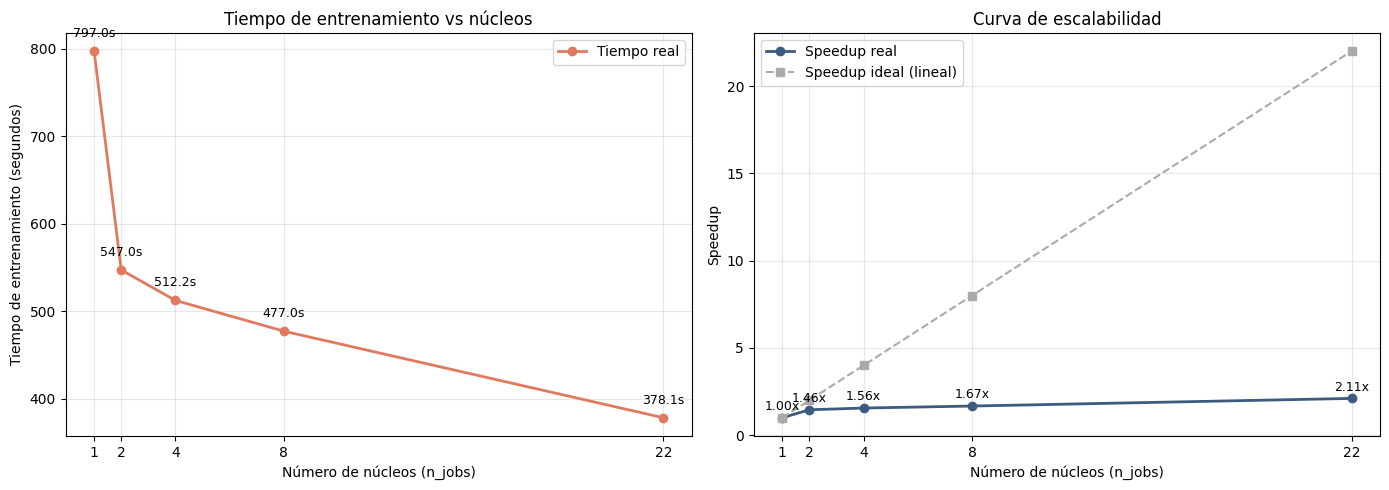

Gráfico guardado como 'escalabilidad.png'


In [19]:
n_jobs_vals = list(resultados_escalabilidad.keys())
tiempos_esc = [resultados_escalabilidad[n]['tiempo_entrenamiento'] for n in n_jobs_vals]
speedups_reales = [t_base / t for t in tiempos_esc]
speedups_ideales = [float(n) for n in n_jobs_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: tiempo de entrenamiento por número de núcleos ---
ax1 = axes[0]
ax1.plot(n_jobs_vals, tiempos_esc, marker='o', color='#E07A5F', linewidth=2, label='Tiempo real')
ax1.set_xlabel('Número de núcleos (n_jobs)')
ax1.set_ylabel('Tiempo de entrenamiento (segundos)')
ax1.set_title('Tiempo de entrenamiento vs núcleos')
ax1.set_xticks(n_jobs_vals)
ax1.grid(alpha=0.3)
ax1.legend()
for x, y in zip(n_jobs_vals, tiempos_esc):
    ax1.text(x, y + max(tiempos_esc)*0.02, f'{y:.1f}s', ha='center', fontsize=9)

# --- Gráfico 2: speedup real vs ideal ---
ax2 = axes[1]
ax2.plot(n_jobs_vals, speedups_reales,  marker='o', color='#3D5A80', linewidth=2, label='Speedup real')
ax2.plot(n_jobs_vals, speedups_ideales, marker='s', color='#aaaaaa', linewidth=1.5,
         linestyle='--', label='Speedup ideal (lineal)')
ax2.set_xlabel('Número de núcleos (n_jobs)')
ax2.set_ylabel('Speedup')
ax2.set_title('Curva de escalabilidad')
ax2.set_xticks(n_jobs_vals)
ax2.grid(alpha=0.3)
ax2.legend()
for x, y in zip(n_jobs_vals, speedups_reales):
    ax2.text(x, y + max(speedups_ideales)*0.02, f'{y:.2f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('escalabilidad.png', dpi=120, bbox_inches='tight')
plt.show()

print("Gráfico guardado como 'escalabilidad.png'")


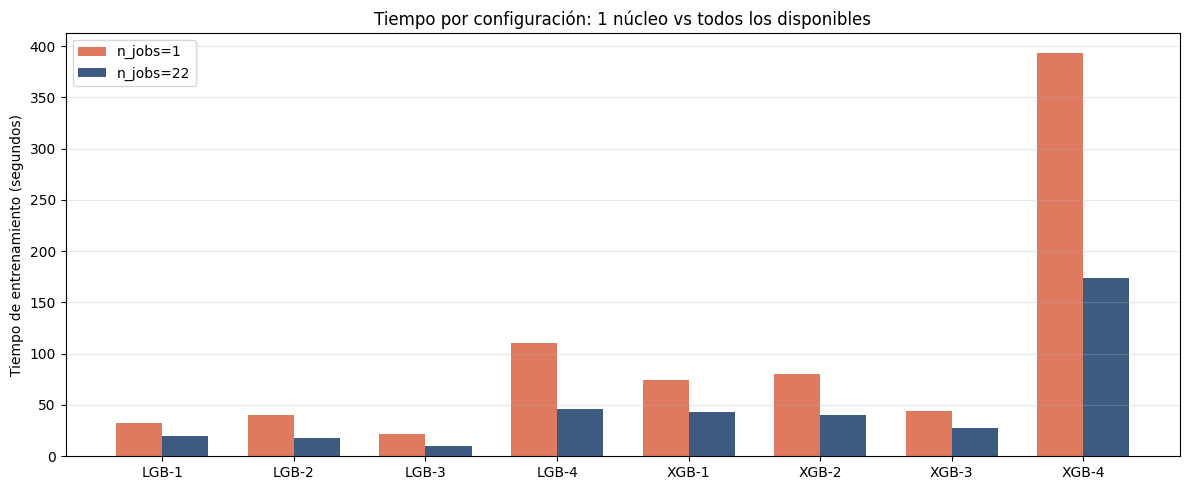

In [20]:
# Comparar el tiempo de entrenamiento del caso base (n_jobs=1)
# vs el de todos los núcleos disponibles, por configuración
resultados_1    = resultados_escalabilidad[1]['resultados']
resultados_max  = resultados_escalabilidad[nucleos_disponibles]['resultados']

df_1   = pd.DataFrame(resultados_1)[['config_id', 'tiempo']].rename(columns={'tiempo': f'n_jobs=1'})
df_max = pd.DataFrame(resultados_max)[['config_id', 'tiempo']].rename(
            columns={'tiempo': f'n_jobs={nucleos_disponibles}'})
df_comp = df_1.merge(df_max, on='config_id')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comp))
ancho = 0.35
ax.bar(x - ancho/2, df_comp['n_jobs=1'],                    ancho,
       label='n_jobs=1',                    color='#E07A5F')
ax.bar(x + ancho/2, df_comp[f'n_jobs={nucleos_disponibles}'], ancho,
       label=f'n_jobs={nucleos_disponibles}', color='#3D5A80')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['config_id'], rotation=0)
ax.set_ylabel('Tiempo de entrenamiento (segundos)')
ax.set_title('Tiempo por configuración: 1 núcleo vs todos los disponibles')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tiempo_por_modelo.png', dpi=120, bbox_inches='tight')
plt.show()


Mejor modelo: LGB-4


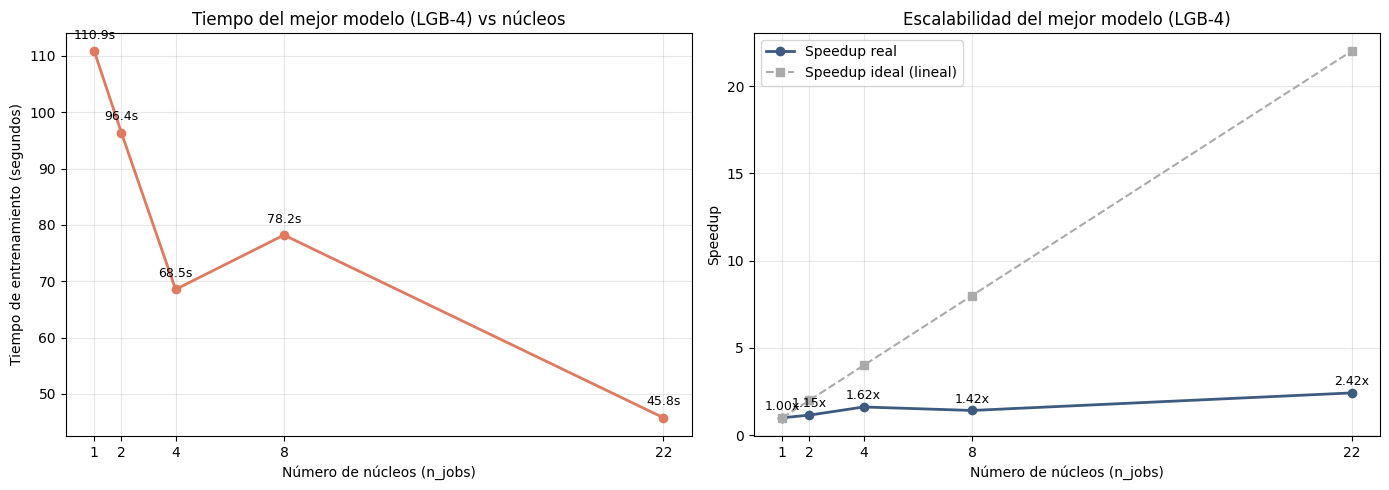

In [21]:
# Identificar el mejor modelo del entrenamiento secuencial
df_sec = pd.DataFrame(resultados_secuencial)
mejor_config_id = df_sec.loc[df_sec['roc_auc'].idxmax(), 'config_id']
print(f"Mejor modelo: {mejor_config_id}")

# Extraer el tiempo de entrenamiento del mejor modelo en cada configuración de núcleos
tiempos_mejor_modelo = []
for n in n_jobs_vals:
    resultados_n = resultados_escalabilidad[n]['resultados']
    df_n = pd.DataFrame(resultados_n)
    t_mejor = df_n.loc[df_n['config_id'] == mejor_config_id, 'tiempo'].values[0]
    tiempos_mejor_modelo.append(t_mejor)

t_base_mejor = tiempos_mejor_modelo[0]  # tiempo con n_jobs=1
speedups_mejor = [t_base_mejor / t for t in tiempos_mejor_modelo]
speedups_ideales_mejor = [float(n) for n in n_jobs_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico izquierdo: tiempo del mejor modelo por número de núcleos ---
ax1 = axes[0]
ax1.plot(n_jobs_vals, tiempos_mejor_modelo, marker='o', color='#E07A5F', linewidth=2)
ax1.set_xlabel('Número de núcleos (n_jobs)')
ax1.set_ylabel('Tiempo de entrenamiento (segundos)')
ax1.set_title(f'Tiempo del mejor modelo ({mejor_config_id}) vs núcleos')
ax1.set_xticks(n_jobs_vals)
ax1.grid(alpha=0.3)
for x, y in zip(n_jobs_vals, tiempos_mejor_modelo):
    ax1.text(x, y + max(tiempos_mejor_modelo) * 0.02, f'{y:.1f}s', ha='center', fontsize=9)

# --- Gráfico derecho: speedup real vs ideal para el mejor modelo ---
ax2 = axes[1]
ax2.plot(n_jobs_vals, speedups_mejor,       marker='o', color='#3D5A80', linewidth=2,
         label='Speedup real')
ax2.plot(n_jobs_vals, speedups_ideales_mejor, marker='s', color='#aaaaaa', linewidth=1.5,
         linestyle='--', label='Speedup ideal (lineal)')
ax2.set_xlabel('Número de núcleos (n_jobs)')
ax2.set_ylabel('Speedup')
ax2.set_title(f'Escalabilidad del mejor modelo ({mejor_config_id})')
ax2.set_xticks(n_jobs_vals)
ax2.grid(alpha=0.3)
ax2.legend()
for x, y in zip(n_jobs_vals, speedups_mejor):
    ax2.text(x, y + max(speedups_ideales_mejor) * 0.02, f'{y:.2f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('escalabilidad_mejor_modelo.png', dpi=120, bbox_inches='tight')
plt.show()
